# Phase 1: MedSAM Segmentation Evaluation Demo (Self-Contained)

This notebook demonstrates the zero-shot segmentation capabilities of the MedSAM foundation model on dermoscopic images.
It is **100% self-contained**, meaning it does not rely on any external `.py` files and can be run anywhere (Kaggle, Colab, or local Jupyter).

## 1. Setup & Imports

In [3]:
!pip install -q segment-anything

import os
from pathlib import Path
import random
from dataclasses import dataclass
from typing import Optional, List, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from skimage import transform as sk_transform
from segment_anything import sam_model_registry

## 2. Core AI Classes
*(These are the exact classes used in our backend engine, pasted here so the notebook works independently)*

In [4]:
@dataclass
class BoundingBox:
    x_min: int
    y_min: int
    x_max: int
    y_max: int

    def to_list(self) -> list:
        return [self.x_min, self.y_min, self.x_max, self.y_max]

    def area(self) -> int:
        return max(0, self.x_max - self.x_min) * max(0, self.y_max - self.y_min)

class LesionLocator:
    def __init__(self, bbox_padding: float = 0.10, min_area_ratio: float = 0.005):
        self.bbox_padding = bbox_padding
        self.min_area_ratio = min_area_ratio

    def locate(self, image: np.ndarray) -> BoundingBox:
        H, W = image.shape[:2]
        min_area = int(H * W * self.min_area_ratio)
        candidates = []

        bbox = self._otsu_strategy(image, min_area)
        if bbox: candidates.append(("otsu", bbox))

        bbox = self._adaptive_strategy(image, min_area)
        if bbox: candidates.append(("adaptive", bbox))

        bbox = self._lab_strategy(image, min_area)
        if bbox: candidates.append(("lab", bbox))

        if not candidates:
            pad_x, pad_y = int(W * 0.1), int(H * 0.1)
            best_bbox = BoundingBox(pad_x, pad_y, W - pad_x, H - pad_y)
        else:
            best_bbox = self._select_best(candidates, H, W)

        return self._pad_and_clamp(best_bbox, H, W)

    def _otsu_strategy(self, image, min_area):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return self._largest_contour_bbox(binary, min_area)

    def _adaptive_strategy(self, image, min_area):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 51, 10)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
        return self._largest_contour_bbox(binary, min_area)

    def _lab_strategy(self, image, min_area):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        blurred = cv2.GaussianBlur(lab[:, :, 0], (5, 5), 0)
        _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return self._largest_contour_bbox(binary, min_area)

    def _largest_contour_bbox(self, binary, min_area):
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid = [c for c in contours if cv2.contourArea(c) >= min_area]
        if not valid: return None
        x, y, w, h = cv2.boundingRect(max(valid, key=cv2.contourArea))
        return BoundingBox(x, y, x + w, y + h)

    def _select_best(self, candidates, H, W):
        center_x, center_y, img_area = W / 2, H / 2, H * W
        best_score, best_bbox = -1, candidates[0][1]
        for _, bbox in candidates:
            area_score = bbox.area() / img_area
            cx, cy = (bbox.x_min + bbox.x_max) / 2, (bbox.y_min + bbox.y_max) / 2
            dist = ((cx - center_x) ** 2 + (cy - center_y) ** 2) ** 0.5
            centrality = 1.0 - (dist / ((center_x ** 2 + center_y ** 2) ** 0.5))
            bw, bh = max(bbox.x_max - bbox.x_min, 1), max(bbox.y_max - bbox.y_min, 1)
            aspect = min(bw, bh) / max(bw, bh)
            score = 0.4 * area_score + 0.35 * centrality + 0.25 * aspect
            if score > best_score:
                best_score, best_bbox = score, bbox
        return best_bbox

    def _pad_and_clamp(self, bbox, H, W):
        pad_x, pad_y = int((bbox.x_max - bbox.x_min) * self.bbox_padding), int((bbox.y_max - bbox.y_min) * self.bbox_padding)
        return BoundingBox(max(0, bbox.x_min - pad_x), max(0, bbox.y_min - pad_y), min(W, bbox.x_max + pad_x), min(H, bbox.y_max + pad_y))

class MedSAMSegmenter:
    def __init__(self, checkpoint_path, device=None, model_type="vit_b", input_size=1024):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.input_size = input_size
        self.model = sam_model_registry[model_type](checkpoint=checkpoint_path).to(self.device)
        self.model.eval()

    @torch.no_grad()
    def segment(self, image: np.ndarray, bbox: list) -> np.ndarray:
        H, W = image.shape[:2]
        img_1024 = sk_transform.resize(image, (self.input_size, self.input_size), order=3, preserve_range=True, anti_aliasing=True).astype(np.uint8)
        img_norm = (img_1024 - img_1024.min()) / np.clip(img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None)
        img_tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(self.device)
        
        bbox_1024 = np.array(bbox, dtype=np.float64)
        bbox_1024[[0, 2]] = bbox_1024[[0, 2]] / W * self.input_size
        bbox_1024[[1, 3]] = bbox_1024[[1, 3]] / H * self.input_size
        bbox_tensor = torch.tensor(bbox_1024[None, :], dtype=torch.float32).to(self.device)
        
        image_embedding = self.model.image_encoder(img_tensor)
        sparse_embeddings, dense_embeddings = self.model.prompt_encoder(points=None, boxes=bbox_tensor, masks=None)
        low_res_masks, _ = self.model.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=self.model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        
        low_res_mask = torch.sigmoid(low_res_masks[0, 0]).cpu().numpy()
        mask_full = sk_transform.resize(low_res_mask, (H, W), order=1, preserve_range=True, anti_aliasing=False)
        binary = (mask_full > 0.5).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        return cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

def compute_segmentation_metrics(pred_mask: np.ndarray, gt_mask: np.ndarray) -> dict:
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    return {
        "dice": float(2.0 * tp / max(pred.sum() + gt.sum(), 1)),
        "iou": float(tp / max(np.logical_or(pred, gt).sum(), 1)),
        "precision": float(tp / max(tp + fp, 1)),
        "recall": float(tp / max(tp + fn, 1)),
    }

## 3. Load Models

In [5]:
print("Initializing Lesion Locator...")
locator = LesionLocator(bbox_padding=0.10)

print("Loading MedSAM Foundation Model...")
# EDIT THIS PATH if running on Kaggle/Colab
segmenter = MedSAMSegmenter(checkpoint_path="../checkpoints/medsam_vit_b.pth")
print("Models loaded successfully!")

Initializing Lesion Locator...
Loading MedSAM Foundation Model...
Models loaded successfully!


## 4. Load Image & Ground Truth
Select an image from the ISIC 2018 dataset to test.

In [6]:
IMAGE_PATH = "C:/Users/shiva/Downloads/ISIC2018_Task1-2_Training_Input/ISIC2018_Task1-2_Training_Input/ISIC_0016061.jpg"
MASK_PATH = "C:/Users/shiva/Downloads/ISIC2018_Task1_Training_GroundTruth/ISIC2018_Task1_Training_GroundTruth/ISIC_0016061_segmentation.png"

try:
    image = np.array(Image.open(IMAGE_PATH).convert("RGB"))
    gt_mask = np.array(Image.open(MASK_PATH).convert("L"))
    gt_mask = (gt_mask > 127).astype(np.uint8)
    print(f"Loaded image shape: {image.shape}")
except Exception as e:
    print(f"Error loading images: {e}\nUpdate IMAGE_PATH and MASK_PATH to valid files.")

Loaded image shape: (2848, 4288, 3)


## 5. Run AI & Calculate Metrics

In [7]:
bbox = locator.locate(image)
print(f"Detected Bounding Box: [X: {bbox.x_min} to {bbox.x_max}, Y: {bbox.y_min} to {bbox.y_max}]")

pred_mask = segmenter.segment(image, bbox.to_list())
metrics = compute_segmentation_metrics(pred_mask, gt_mask)

print("\n--- Segmentation Metrics ---")
print(f"⭐ Dice Score: {metrics['dice']:.4f}")
print(f"⭐ IoU Score:  {metrics['iou']:.4f}")
print(f"Precision:    {metrics['precision']:.4f}")
print(f"Recall:       {metrics['recall']:.4f}")

Detected Bounding Box: [X: 1916 to 2295, Y: 1501 to 1899]

--- Segmentation Metrics ---
⭐ Dice Score: 0.7988
⭐ IoU Score:  0.6651
Precision:    1.0000
Recall:       0.6651


## 6. Visualization

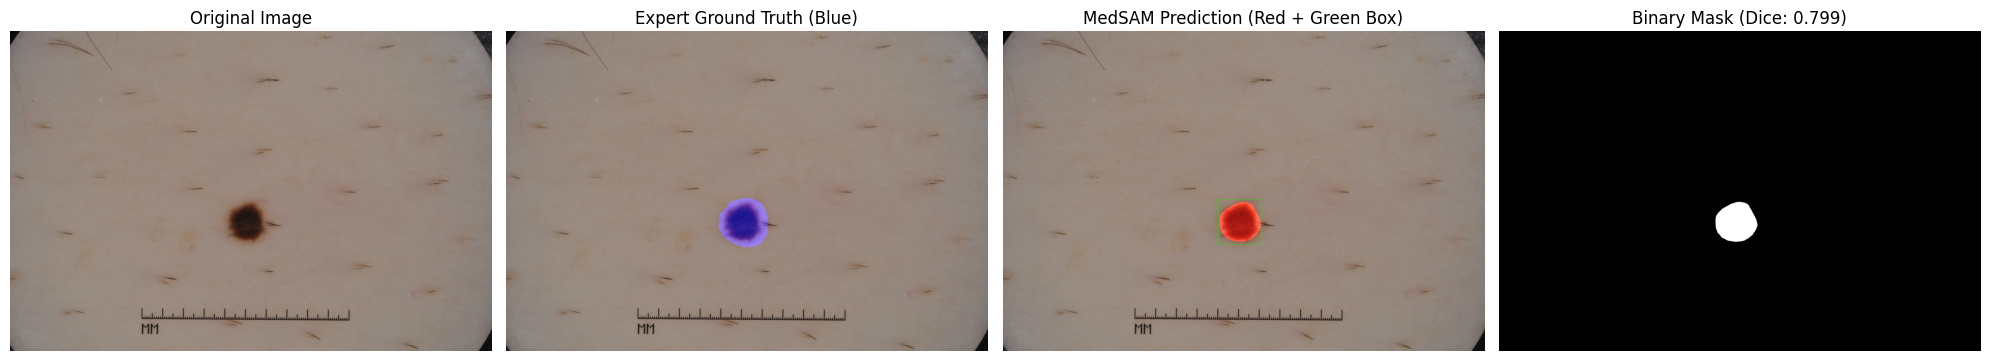

In [8]:
overlay_pred = image.copy()
overlay_gt = image.copy()

red_mask = np.zeros_like(image)
red_mask[:, :, 0] = pred_mask * 255
overlay_pred = cv2.addWeighted(overlay_pred, 1.0, red_mask, 0.5, 0)
cv2.rectangle(overlay_pred, (bbox.x_min, bbox.y_min), (bbox.x_max, bbox.y_max), (0, 255, 0), 2)

blue_mask = np.zeros_like(image)
blue_mask[:, :, 2] = gt_mask * 255
overlay_gt = cv2.addWeighted(overlay_gt, 1.0, blue_mask, 0.5, 0)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image); axes[0].set_title("Original Image")
axes[1].imshow(overlay_gt); axes[1].set_title("Expert Ground Truth (Blue)")
axes[2].imshow(overlay_pred); axes[2].set_title("MedSAM Prediction (Red + Green Box)")
axes[3].imshow(pred_mask, cmap="gray"); axes[3].set_title(f"Binary Mask (Dice: {metrics['dice']:.3f})")

for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()